# 02 — Dark Matter Annihilation Model

WIMP annihilation in dark matter halos produces gamma-ray photons.
This notebook traces the signal chain: particle-physics photon yield
(PPPC4DMID, Cirelli+ 2011), EBL absorption (Dominguez+ 2011), NFW density-squared
profile, substructure boost (Moline+ 2017), and clumping factor $\Delta^2(z)$,
culminating in the DM window function $W_\gamma^\mathrm{DM}$.

**References:** `docs/equations.md` §4 (Eqs. 4.1–4.8), §6 (PPPC4DMID), §7 (EBL).

In [25]:
import sys
from pathlib import Path

def _find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / 'pyproject.toml').exists() and (candidate / 'hi_gamma_xcorr').is_dir():
            return candidate
    raise RuntimeError(f'Could not locate repo root from {start}')

REPO_ROOT = _find_repo_root(Path.cwd())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import matplotlib.pyplot as plt
from hi_gamma_xcorr import config as cfg, cosmology as cosmo
from hi_gamma_xcorr import plotting as sty
cosmo.init()
print("Pipeline initialized.")

Pipeline initialized.


In [26]:
from hi_gamma_xcorr import halo_model as hm, dm_model as dm, pppc4dmid, ebl

\
## 1. PPPC4DMID Photon Yields (Eq. 6.1)

$x = E/m_\chi$; the table gives $dN/dx$ per annihilation for each channel.

In [ ]:
x = np.logspace(-5, -0.01, 200)
fig, axes = plt.subplots(1, 3, figsize=(sty.TEXTWIDTH_IN * 1.8, sty.TEXTWIDTH_IN * 0.45))
for ax, ch, title in zip(axes, ['bb', 'tautau', 'WW'],
                          [r'$b\bar{b}$', r'$\tau^+\tau^-$', r'$W^+W^-$']):
    for m, color in [(10, 'C0'), (100, 'C1'), (1000, 'C2')]:
        dndx = pppc4dmid.dNdx(x, m, ch)
        ax.loglog(x, x**2 * dndx, color=color, lw=sty.LW_STANDARD,
                  label=rf'$m_\chi={m}$ GeV')
    ax.set_xlabel(r'$x = E/m_\chi$'); ax.set_title(title)
    ax.set_xlim(1e-5, 1); ax.legend(fontsize=6)
axes[0].set_ylabel(r'$x^2\,dN/dx$')
fig.suptitle('PPPC4DMID Photon Yields'); fig.tight_layout()

\
## 2. EBL Optical Depth and Attenuation (Eqs. 7.1–7.2)

$$\tau(E, z)$$ from Dominguez et al. (2011); the universe is transparent at $E < 10$ GeV.

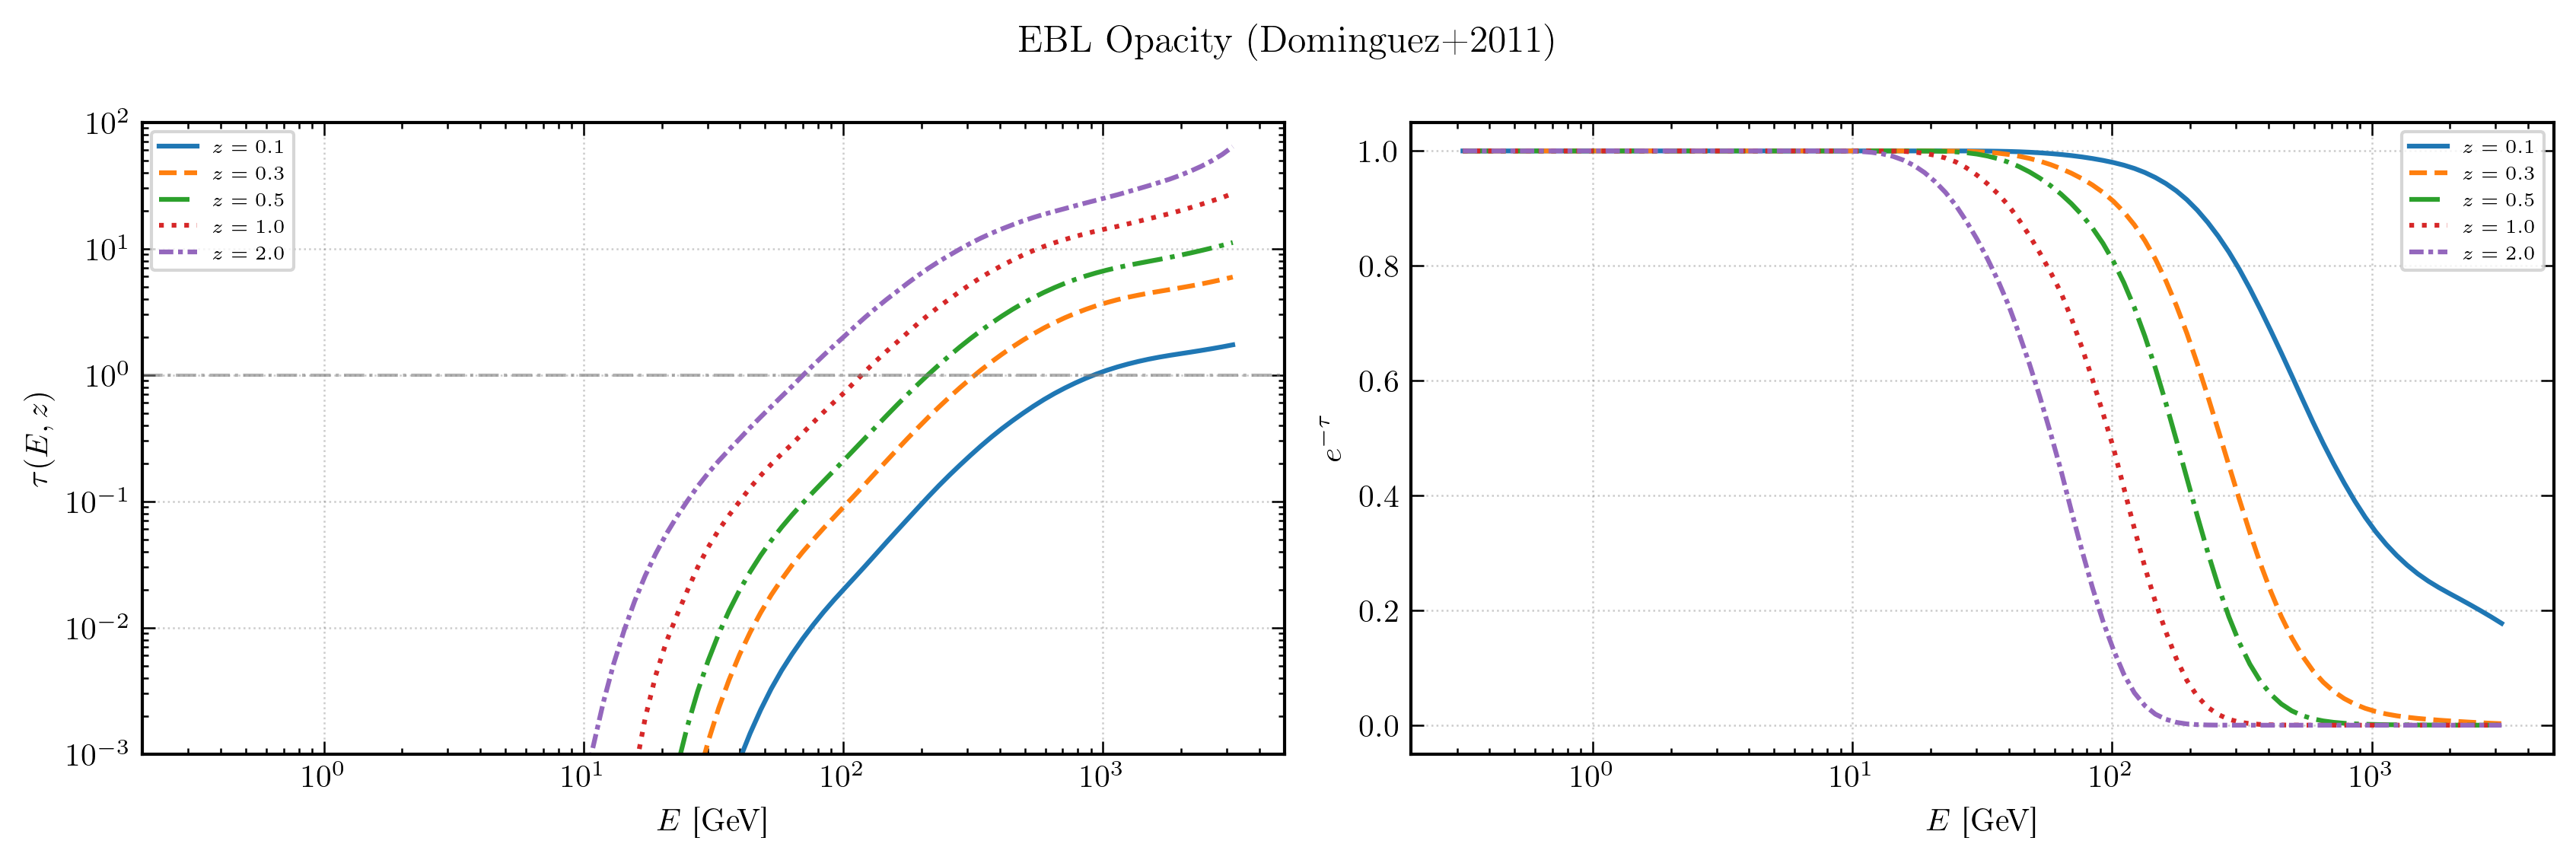

In [28]:
E_ebl = np.logspace(-0.5, 3.5, 100)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(sty.TEXTWIDTH_IN * 1.5, sty.TEXTWIDTH_IN * 0.5))
for z, ls in [(0.1, '-'), (0.3, '--'), (0.5, '-.'), (1.0, ':'), (2.0, (0,(3,1,1,1)))]:
    t = ebl.tau(E_ebl, z)
    ax1.semilogy(E_ebl, t, ls=ls, lw=sty.LW_STANDARD, label=f'$z={z}$')
    ax2.semilogx(E_ebl, ebl.attenuation(E_ebl, z), ls=ls, lw=sty.LW_STANDARD, label=f'$z={z}$')
ax1.axhline(1, **sty.GUIDE_STYLE); ax1.set_xscale('log')
ax1.set_xlabel('$E$ [GeV]'); ax1.set_ylabel(r'$\tau(E,z)$')
ax1.set_ylim(1e-3, 100); ax1.legend(fontsize=6)
ax2.set_xlabel('$E$ [GeV]'); ax2.set_ylabel(r'$e^{-\tau}$')
ax2.set_xscale('log'); ax2.legend(fontsize=6)
fig.suptitle('EBL Opacity (Dominguez+2011)'); fig.tight_layout()

\
## 3. DM Halo Structure

Virial radius $R_\mathrm{vir}$, concentration $c_\mathrm{vir}(M,z)$ from
Correa+ (2015), and NFW scale density $\rho_s$.

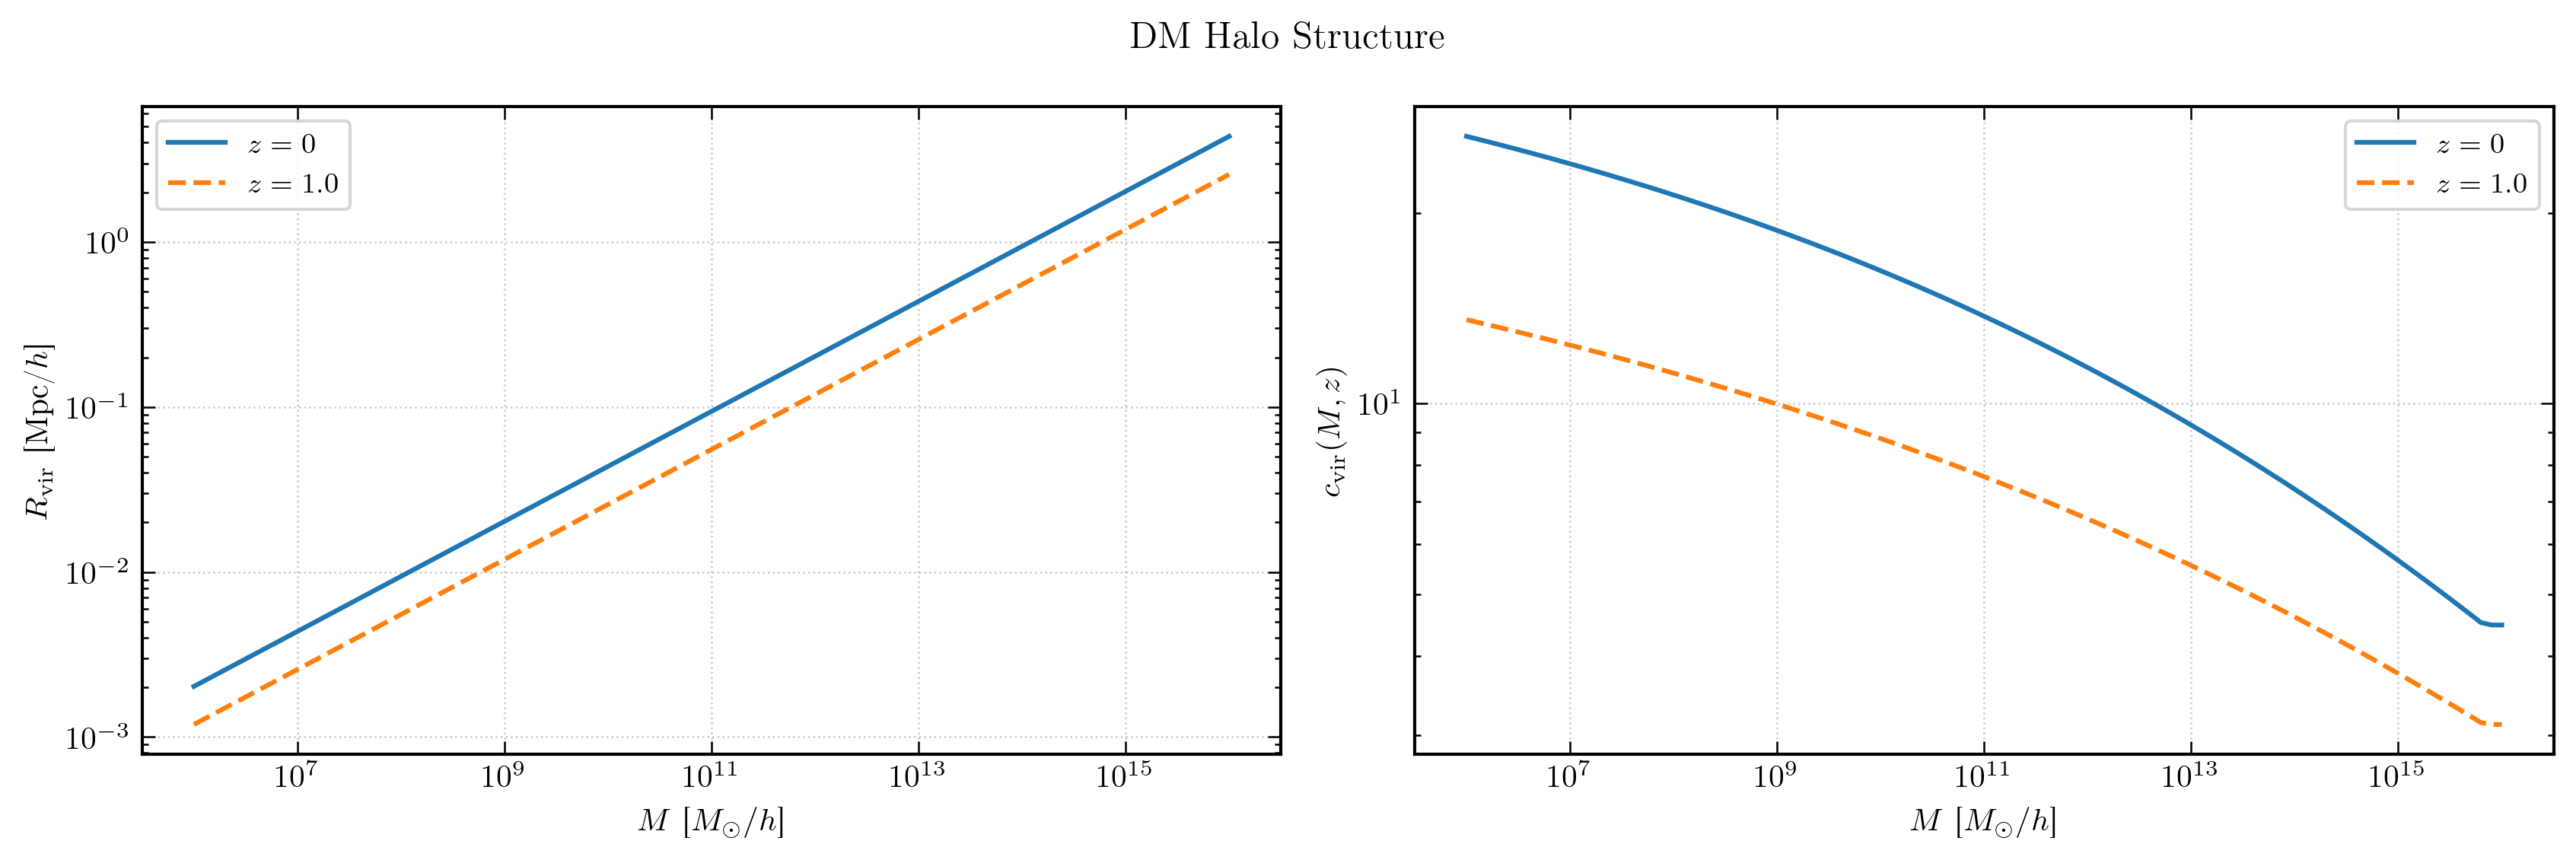

In [29]:
M_dm = np.logspace(6, 16, 100)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(sty.TEXTWIDTH_IN * 1.5, sty.TEXTWIDTH_IN * 0.5))
for z, ls in [(0, '-'), (1.0, '--')]:
    ax1.loglog(M_dm, [hm.R_vir(M, z) for M in M_dm], ls=ls, lw=sty.LW_STANDARD, label=f'$z={z}$')
    ax2.loglog(M_dm, [hm.concentration(M, z) for M in M_dm], ls=ls, lw=sty.LW_STANDARD, label=f'$z={z}$')
ax1.set_xlabel(r'$M$ [$M_\odot/h$]'); ax1.set_ylabel(r'$R_\mathrm{vir}$ [Mpc/$h$]')
ax2.set_xlabel(r'$M$ [$M_\odot/h$]'); ax2.set_ylabel(r'$c_\mathrm{vir}(M,z)$')
ax1.legend(); ax2.legend()
fig.suptitle('DM Halo Structure'); fig.tight_layout()

\
## 4. Substructure Boost Factor (Eqs. 4.4a–4.4b)

$$B(M,z) = \frac{B(M,z{=}0)}{1+z},\qquad
\log_{10}B(M,0) = \sum_{i=0}^{5} b_i\,[\log_{10}(M/M_\odot)]^i$$

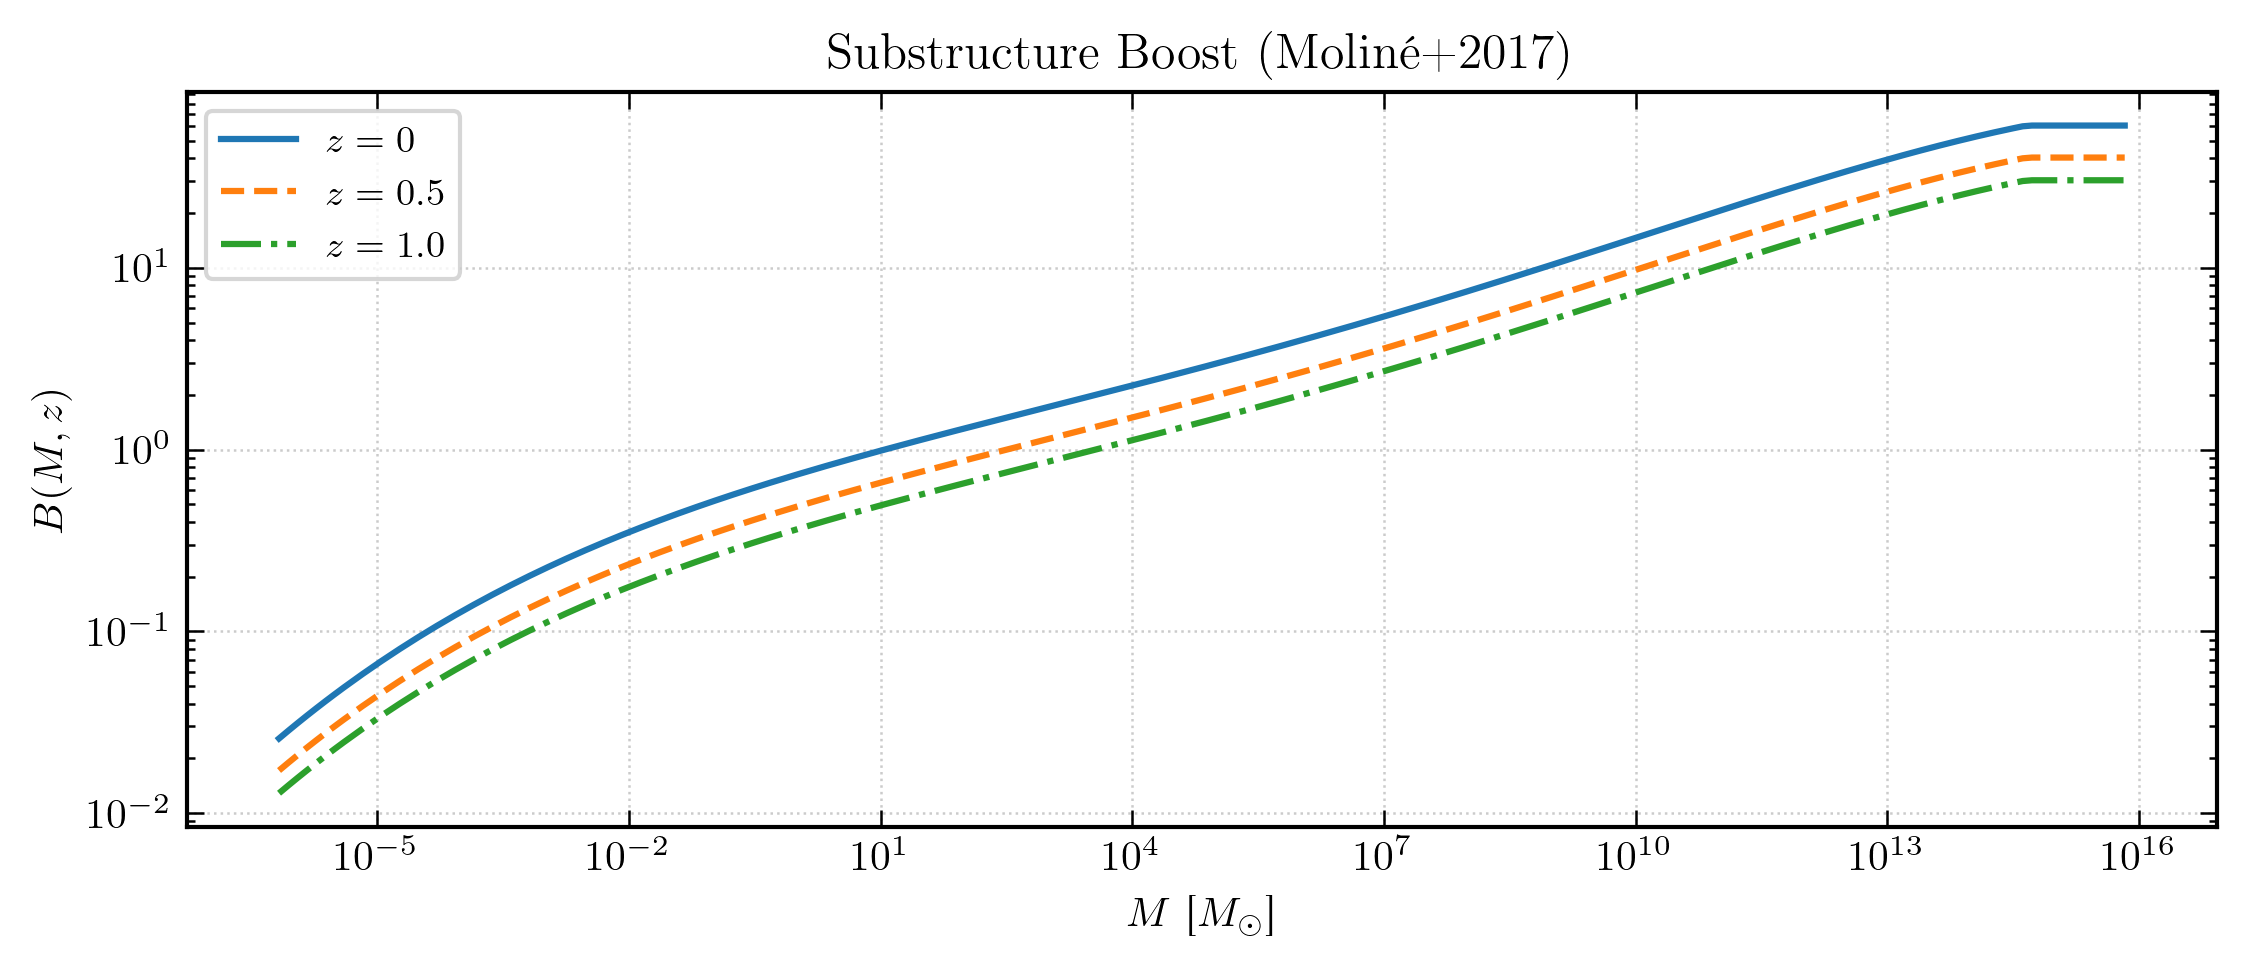

In [30]:
M_boost = np.logspace(-6, 16, 200)
fig, ax = sty.textwidth_figure(7)
for z, ls in [(0, '-'), (0.5, '--'), (1.0, '-.')]:
    B = dm.boost_moline(M_boost, z)
    ax.loglog(M_boost * cfg.h, B, ls=ls, lw=sty.LW_STANDARD, label=f'$z={z}$')
ax.set_xlabel(r'$M$ [$M_\odot$]'); ax.set_ylabel(r'$B(M,z)$')
ax.set_title(r'Substructure Boost (Molin\'e+2017)'); ax.legend(); fig.tight_layout()

\
## 5. Clumping Factor $\Delta^2(z)$ (Eq. 4.5)

$$\Delta^2(z) = \frac{1}{\bar\rho_m^2(1+z)^3}\int\frac{dn}{dM}\,[1+B(M,z)]\,
\int\rho_\mathrm{NFW}^2\,d^3x\,dM$$

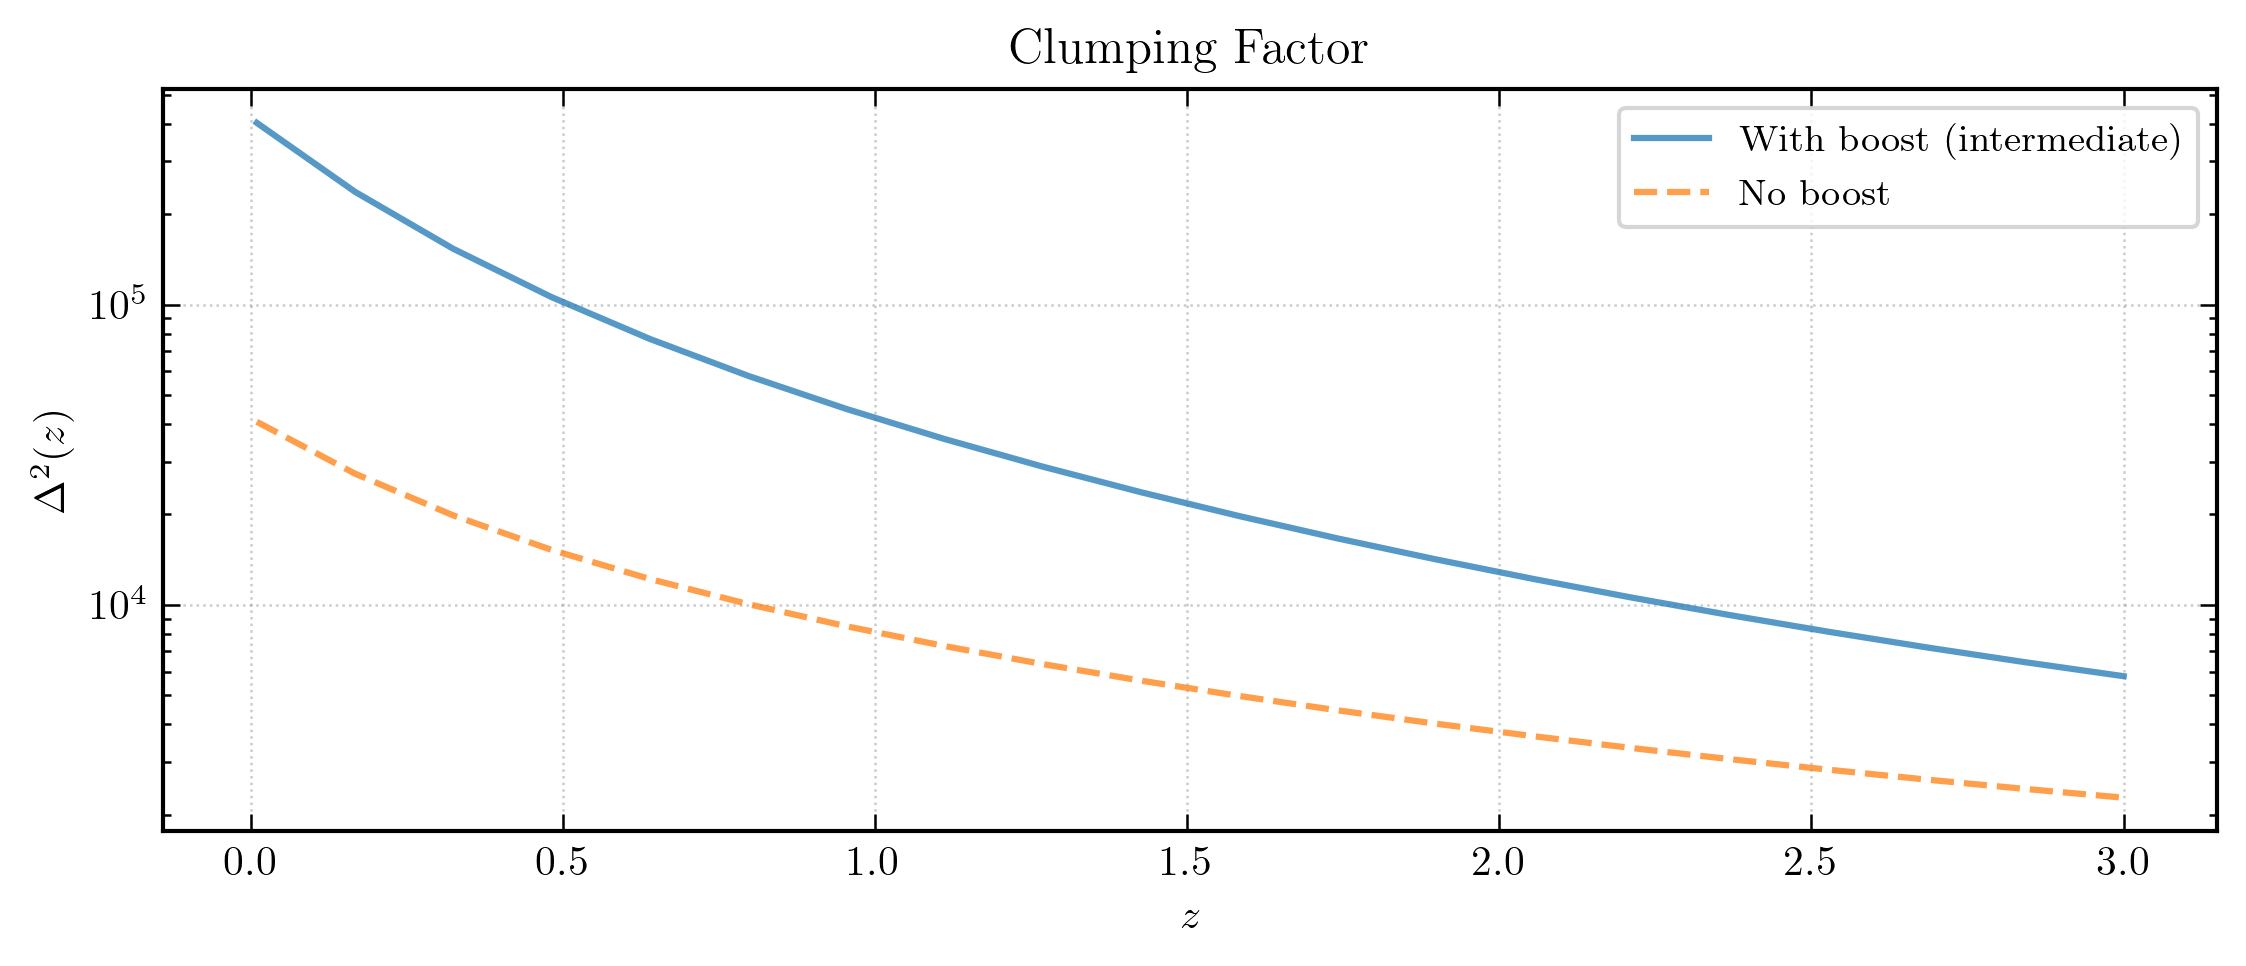

In [31]:
z_cl = np.linspace(0.01, 3.0, 20)
D2_boost = np.array([dm.clumping_factor(z) for z in z_cl])
D2_noboost = np.array([dm.clumping_factor(z, boost_scenario='no_boost') for z in z_cl])

fig, ax = sty.textwidth_figure(7)
ax.semilogy(z_cl, D2_boost, **sty.FIT_STYLE, label='With boost (intermediate)')
ax.semilogy(z_cl, D2_noboost, **sty.MODEL_STYLE, label='No boost')
ax.set_xlabel('$z$'); ax.set_ylabel(r'$\Delta^2(z)$')
ax.set_title('Clumping Factor'); ax.legend(); fig.tight_layout()

\
## 6. DM Window Function $W_\gamma^\mathrm{DM}$ (Eq. 4.6)

$$W_\gamma^\mathrm{DM}(\chi) = \frac{\langle\sigma v\rangle}{8\pi}
\left(\frac{\rho_\mathrm{DM}}{m_\chi}\right)^2(1+z)^3\,\Delta^2\,
\frac{dN}{dE'}\,e^{-\tau}$$

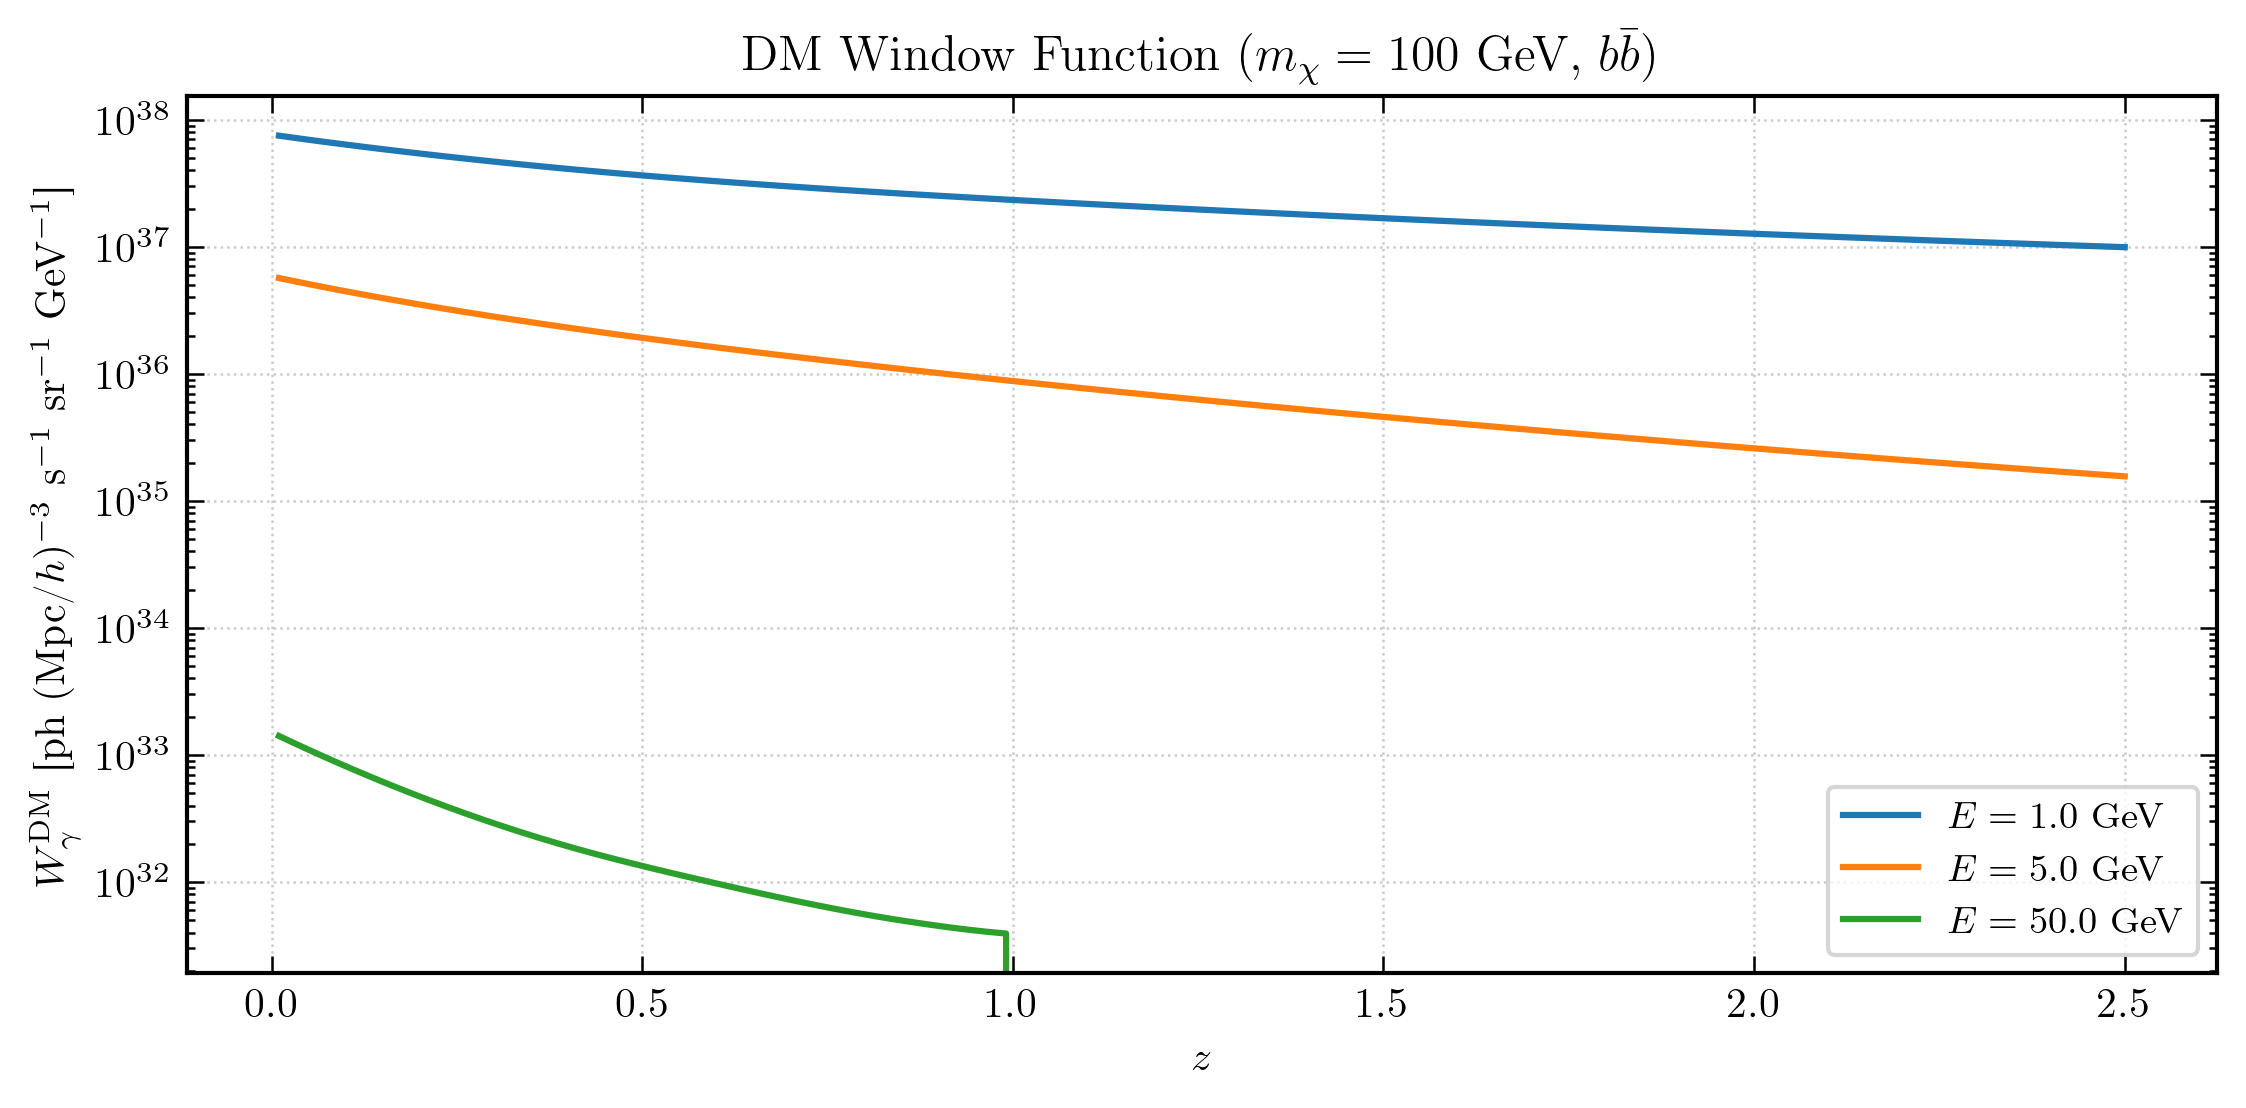

In [32]:
z_dm = np.linspace(0.01, 2.5, 100)
fig, ax = sty.textwidth_figure(8)
for E, color in [(1.0, 'C0'), (5.0, 'C1'), (50.0, 'C2')]:
    W = np.array([dm.W_gamma_DM(E, z, 100.0) for z in z_dm])
    ax.semilogy(z_dm, W, color=color, lw=sty.LW_STANDARD, label=f'$E={E}$ GeV')
ax.set_xlabel('$z$')
ax.set_ylabel(r'$W_\gamma^\mathrm{DM}$ [ph (Mpc/$h$)$^{-3}$ s$^{-1}$ sr$^{-1}$ GeV$^{-1}$]')
ax.set_title(r'DM Window Function ($m_\chi=100$ GeV, $b\bar{b}$)')
ax.legend(); fig.tight_layout()